Question: What customer types exist?

In [2]:
#IMport library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [3]:
#load dataset
df = pd.read_csv("/home/vaidehi-deogade/Desktop/Konverge/Projects/olist_ml_analytics/raw_data/processed_data/cleaned_dataset.csv")
df.head()

,Unnamed: 0,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,...,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,credit_card,1.0,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
1,1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,voucher,1.0,2.00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
2,2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1.0,...,voucher,1.0,18.59,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,housewares
3,3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1.0,...,boleto,1.0,141.46,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumery
4,4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1.0,...,credit_card,3.0,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,auto


In [4]:
#Convert to datetime
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])


In [5]:
#Create  rfm(recency(recent customer purchase),frequency(no of orders),monetary(total spend))

snap_date = df['order_purchase_timestamp'].max()+pd.Timedelta(days=1)

#Create customer lvel rfm dataset
rfm_df = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': max,    #last purchase date
    'order_id': 'nunique',  #no of orders
    'payment_value': 'sum'  #total spend
}).reset_index()

# Rename columns
rfm_df.columns = ['customer_id', 'max_date', 'frequency', 'monetary']

#Calculate Recency (Days since last purchase): Subtracting the customer's last date from our snap_date
rfm_df['recency'] = (snap_date - rfm_df['max_date']).dt.days

#Finalize the RFM table (drop the helper date column)
rfm_df = rfm_df[['customer_id', 'recency', 'frequency', 'monetary']]

rfm_df.head()

/tmp/ipykernel_5519/1712976878.py:6: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  rfm_df = df.groupby('customer_unique_id').agg({


,customer_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19
2,0000f46a3911fa3c0805444483337064,542,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,293,1,196.89


In [6]:
#handle outliers
rfm=rfm_df[(rfm_df['monetary']>0)]

In [7]:
#feature scaling
features_to_scale = ['recency', 'frequency', 'monetary']

# 2. Extract just the values
# .values ensures we are passing a clean numpy array to the scaler
rfm_numeric = rfm[features_to_scale]

# 3. Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_numeric)
#Without scaling → large values dominate clustering.
print("Data Prepared and Scaled.")

Data Prepared and Scaled.


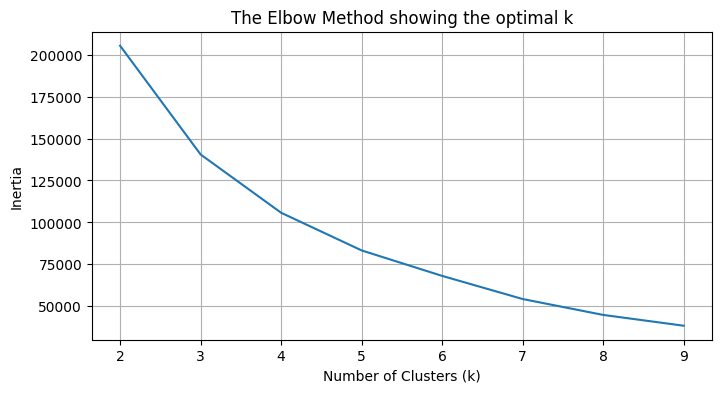

In [8]:
#Elbow method: how many clusters we need
inertia = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(2,10),inertia)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.grid(True)
plt.show()


In [9]:
#KMeans clustering
#apply
kmeans = KMeans(n_clusters=4, random_state=42,n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

rfm_df['kmeans_cluster'] = kmeans_labels


In [10]:
#evaluate by silhouette

kmeans_score = silhouette_score(X_scaled,kmeans_labels)
print("KMeans Silhouette Score:", round(kmeans_score,3))

KMeans Silhouette Score: 0.527


In [11]:
# Check if one cluster is huge and others are tiny
print(pd.Series(kmeans_labels).value_counts())


3    52621
0    39191
2     2861
1       21
Name: count, dtype: int64


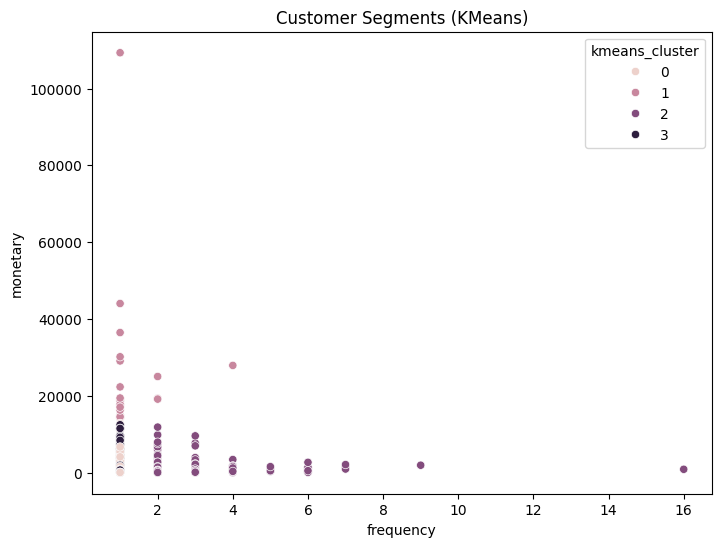

In [12]:
#visualize Kmean clusters
# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
# sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=kmeans_labels, palette='Set2')
sns.scatterplot(x=rfm_df['frequency'],y=rfm_df['monetary'],hue=rfm_df['kmeans_cluster'])
plt.title("Customer Segments (KMeans)")
# plt.xlabel("PCA 1")
# plt.ylabel("PCA 2")
plt.show()